In [1]:
# Instala AutoGluon
!pip install autogluon

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.5/259.5 kB 7.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of openxlab to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of openxlab to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
   ━━━━━━━━━━━━━━━

In [2]:

# Importo librerías
import pandas as pd
from autogluon.tabular import TabularPredictor

# obtener desde GitHub
red = "https://raw.githubusercontent.com/jesustristan17/Curso-Machine-Learning/main/datasets/Wine_Quality/winequality-red%5B1%5D.csv"
white = "https://raw.githubusercontent.com/jesustristan17/Curso-Machine-Learning/main/datasets/Wine_Quality/winequality-white%5B1%5D.csv"

# Cargar los datos
df_red = pd.read_csv(red, sep=';')
df_white = pd.read_csv(white, sep=';')

# Combinar ambos datasets
df = pd.concat([df_red, df_white], ignore_index=True)

# Definir columna objetivo
label = 'quality'

# Dividir en train/test
train_data = df.sample(frac=0.8, random_state=42)
test_data = df.drop(train_data.index)

# Entrenar AutoML
predictor = TabularPredictor(label=label, eval_metric='roc_auc_ovo').fit(train_data)

# Evaluar en test
performance = predictor.evaluate(test_data)
print("Performance general:", performance)

# Predicciones
preds = predictor.predict(test_data)
print("Predicciones ejemplo:")
print(preds.head())

# Leaderboard: modelos y métricas
lb_df = predictor.leaderboard(test_data, silent=True)
print("Leaderboard:")
print(lb_df)

# Exportar leaderboard a CSV
lb_df.to_csv("leaderboard_winequality.csv", index=False)
print("Leaderboard exportado como 'leaderboard_winequality.csv'")


No path specified. Models will be saved in: "AutogluonModels/ag-20250926_022128"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.4.0
Python Version:     3.12.11
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP PREEMPT_DYNAMIC Sat Sep  6 09:54:41 UTC 2025
CPU Count:          2
Memory Avail:       11.42 GB / 12.67 GB (90.1%)
Disk Space Avail:   62.31 GB / 107.72 GB (57.8%)
No presets specified! To achieve strong results with AutoGluon, it is recommended to use the available presets. Defaulting to `'medium'`...
	Recommended Presets (For more details refer to https://auto.gluon.ai/stable/tutorials/tabular/tabular-essentials.html#presets):
	presets='extreme' : New in v1.4: Massively better than 'best' on datasets <30000 samples by using new models meta-learned on https://tabarena.ai: TabPFNv2, TabICL, Mitra, and TabM. Absolute best accuracy. Requires a GPU. Recommended 64 GB CPU memory and 32+ GB GPU me

[1000]	valid_set's multi_logloss: 0.997465	valid_set's roc_auc_ovo: 0.811476


	0.8153	 = Validation score   (roc_auc_ovo)
	47.16s	 = Training   runtime
	0.5s	 = Validation runtime
Fitting model: LightGBM ...
	Fitting with cpus=1, gpus=0, mem=0.0/10.9 GB


[1000]	valid_set's multi_logloss: 1.49747	valid_set's roc_auc_ovo: 0.834806
[2000]	valid_set's multi_logloss: 2.03553	valid_set's roc_auc_ovo: 0.842002


	0.8455	 = Validation score   (roc_auc_ovo)
	83.41s	 = Training   runtime
	1.44s	 = Validation runtime
Fitting model: RandomForestGini ...
	Fitting with cpus=2, gpus=0, mem=0.0/10.9 GB
	0.8467	 = Validation score   (roc_auc_ovo)
	4.58s	 = Training   runtime
	0.12s	 = Validation runtime
Fitting model: RandomForestEntr ...
	Fitting with cpus=2, gpus=0, mem=0.0/10.9 GB
	0.7862	 = Validation score   (roc_auc_ovo)
	4.41s	 = Training   runtime
	0.11s	 = Validation runtime
Fitting model: CatBoost ...
	Fitting with cpus=1, gpus=0
	0.8385	 = Validation score   (roc_auc_ovo)
	58.14s	 = Training   runtime
	0.01s	 = Validation runtime
Fitting model: ExtraTreesGini ...
	Fitting with cpus=2, gpus=0, mem=0.0/10.8 GB
	0.8186	 = Validation score   (roc_auc_ovo)
	2.27s	 = Training   runtime
	0.11s	 = Validation runtime
Fitting model: ExtraTreesEntr ...
	Fitting with cpus=2, gpus=0, mem=0.0/10.8 GB
	0.8276	 = Validation score   (roc_auc_ovo)
	2.1s	 = Training   runtime
	0.13s	 = Validation runtime
Fittin

[1000]	valid_set's multi_logloss: 1.80762	valid_set's roc_auc_ovo: 0.828254


	0.8313	 = Validation score   (roc_auc_ovo)
	50.96s	 = Training   runtime
	1.51s	 = Validation runtime
Fitting model: WeightedEnsemble_L2 ...
	Ensemble Weights: {'ExtraTreesEntr': 0.5, 'RandomForestGini': 0.167, 'CatBoost': 0.167, 'NeuralNetTorch': 0.167}
	0.8655	 = Validation score   (roc_auc_ovo)
	4.79s	 = Training   runtime
	0.03s	 = Validation runtime
AutoGluon training complete, total runtime = 323.91s ... Best model: WeightedEnsemble_L2 | Estimated inference throughput: 1661.7 rows/s (520 batch size)
TabularPredictor saved. To load, use: predictor = TabularPredictor.load("/content/AutogluonModels/ag-20250926_022128")


Performance general: {'roc_auc_ovo': np.float64(0.8744446099525383), 'accuracy': 0.7036181678214011, 'balanced_accuracy': np.float64(0.43624477485038243), 'mcc': np.float64(0.5424708497258396)}
Predicciones ejemplo:
3     5
4     5
5     5
9     5
16    5
Name: quality, dtype: int64
Leaderboard:
                  model  score_test  score_val  eval_metric  pred_time_test  \
0        ExtraTreesGini    0.878488   0.818602  roc_auc_ovo        0.225398   
1      RandomForestGini    0.876464   0.846724  roc_auc_ovo        0.238965   
2   WeightedEnsemble_L2    0.874445   0.865516  roc_auc_ovo        0.659883   
3        ExtraTreesEntr    0.873591   0.827589  roc_auc_ovo        0.344855   
4      RandomForestEntr    0.869035   0.786233  roc_auc_ovo        0.219925   
5         LightGBMLarge    0.861612   0.831272  roc_auc_ovo        3.892839   
6              CatBoost    0.856256   0.838531  roc_auc_ovo        0.035175   
7               XGBoost    0.849713   0.799819  roc_auc_ovo        0.17

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score
import plotly.graph_objects as go

# === Reporte de Clasificación ===
print("Reporte de Clasificación:")
print(classification_report(test_data[label], preds, digits=3))


Reporte de Clasificación:
              precision    recall  f1-score   support

           3      0.000     0.000     0.000         7
           4      1.000     0.068     0.128        44
           5      0.743     0.723     0.733       433
           6      0.668     0.799     0.728       567
           7      0.713     0.617     0.662       209
           8      1.000     0.410     0.582        39

    accuracy                          0.704      1299
   macro avg      0.687     0.436     0.472      1299
weighted avg      0.718     0.704     0.690      1299



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [4]:
# obtener desde GitHub
url_flu_codificado = "https://raw.githubusercontent.com/jesustristan17/Curso-Machine-Learning/refs/heads/main/datasets/Flu%20Shot%20Learning/flu_filtrado_codificado.csv"
url_flu_test = "https://raw.githubusercontent.com/jesustristan17/Curso-Machine-Learning/refs/heads/main/datasets/Flu%20Shot%20Learning/flu_test_final_codificado.csv"

# Carga los datos
flu_codificado = pd.read_csv(url_flu_codificado)
print(flu_codificado.head())

flu_test = pd.read_csv(url_flu_test)
print(flu_test.head())

   opinion_seas_vacc_effective  opinion_seas_risk  doctor_recc_seasonal  \
0                          2.0                1.0                   0.0   
1                          4.0                2.0                   0.0   
2                          4.0                1.0                   0.0   
3                          5.0                4.0                   1.0   
4                          3.0                1.0                   0.0   

   age_group  opinion_h1n1_risk  opinion_h1n1_vacc_effective  \
0          3                1.0                          3.0   
1          1                4.0                          5.0   
2          0                1.0                          3.0   
3          4                3.0                          3.0   
4          2                3.0                          3.0   

   employment_industry  doctor_recc_h1n1  employment_occupation  \
0                   11               0.0                     11   
1                   13        

In [5]:
# Definir columna objetivo
label = 'seasonal_vaccine'

# Dividir en train/test
train_data = flu_codificado.sample(frac=0.8, random_state=42)
test_data = flu_codificado.drop(train_data.index)

# Entrenar AutoML
predictor = TabularPredictor(label=label, eval_metric='roc_auc').fit(train_data)

# Evaluar en test
performance = predictor.evaluate(test_data)
print("Performance general:", performance)

# Predicciones
preds = predictor.predict(test_data)
print("Predicciones ejemplo:")
print(preds.head())

# Leaderboard: modelos y métricas
lb_df = predictor.leaderboard(test_data, silent=True)
print("Leaderboard:")
print(lb_df)

# Exportar leaderboard a CSV
lb_df.to_csv("leaderboard_winequality.csv", index=False)
print("Leaderboard exportado como 'leaderboard_winequality.csv'")

No path specified. Models will be saved in: "AutogluonModels/ag-20250926_022709"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.4.0
Python Version:     3.12.11
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP PREEMPT_DYNAMIC Sat Sep  6 09:54:41 UTC 2025
CPU Count:          2
Memory Avail:       11.02 GB / 12.67 GB (87.0%)
Disk Space Avail:   61.80 GB / 107.72 GB (57.4%)
No presets specified! To achieve strong results with AutoGluon, it is recommended to use the available presets. Defaulting to `'medium'`...
	Recommended Presets (For more details refer to https://auto.gluon.ai/stable/tutorials/tabular/tabular-essentials.html#presets):
	presets='extreme' : New in v1.4: Massively better than 'best' on datasets <30000 samples by using new models meta-learned on https://tabarena.ai: TabPFNv2, TabICL, Mitra, and TabM. Absolute best accuracy. Requires a GPU. Recommended 64 GB CPU memory and 32+ GB GPU me

Performance general: {'roc_auc': np.float64(0.8644380916249895), 'accuracy': 0.7865568245646882, 'balanced_accuracy': np.float64(0.7843384912439147), 'mcc': np.float64(0.5688900270695921), 'f1': 0.7630922693266833, 'precision': 0.7646813827571846, 'recall': 0.7615097469929489}
Predicciones ejemplo:
9     0
11    0
13    0
16    1
24    0
Name: seasonal_vaccine, dtype: int64
Leaderboard:
                  model  score_test  score_val eval_metric  pred_time_test  \
0   WeightedEnsemble_L2    0.864438   0.857086     roc_auc        0.344375   
1              CatBoost    0.864180   0.855789     roc_auc        0.036284   
2              LightGBM    0.863235   0.855409     roc_auc        0.053724   
3               XGBoost    0.862622   0.853418     roc_auc        0.039038   
4         LightGBMLarge    0.860054   0.852967     roc_auc        0.090196   
5       NeuralNetFastAI    0.855669   0.848976     roc_auc        0.119742   
6        NeuralNetTorch    0.855215   0.850217     roc_auc      

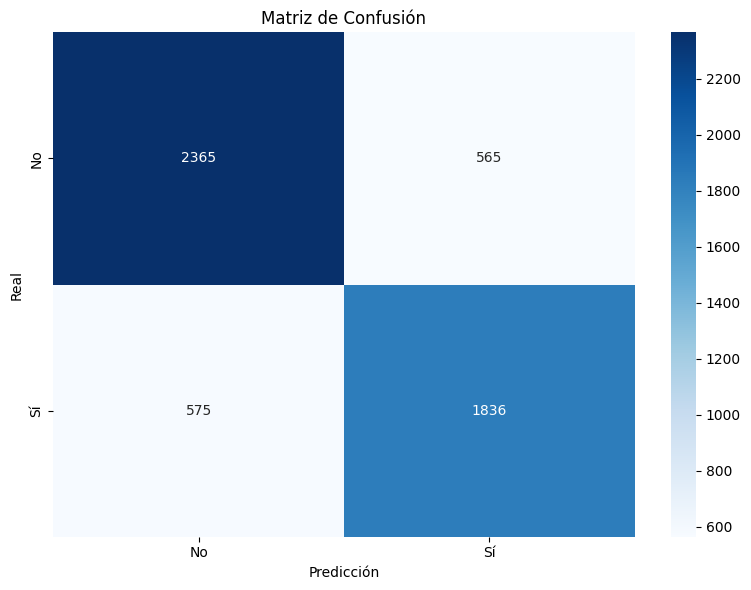

Reporte de Clasificación:
              precision    recall  f1-score   support

           0      0.804     0.807     0.806      2930
           1      0.765     0.762     0.763      2411

    accuracy                          0.787      5341
   macro avg      0.785     0.784     0.784      5341
weighted avg      0.786     0.787     0.787      5341



In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score
import plotly.graph_objects as go

# === Matriz de Confusión ===
plt.figure(figsize=(8, 6))
cm = confusion_matrix(test_data[label], preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No', 'Sí'], yticklabels=['No', 'Sí'])
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión")
plt.tight_layout()
plt.show()

# === Reporte de Clasificación ===
print("Reporte de Clasificación:")
print(classification_report(test_data[label], preds, digits=3))

# === Curva ROC ===
# Obtener probabilidades para la clase positiva (1)
probs = predictor.predict_proba(test_data)[1]

fpr, tpr, thresholds = roc_curve(test_data[label], probs)
auc_score = roc_auc_score(test_data[label], probs)

# Gráfico interactivo con Plotly
fig = go.Figure()
fig.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines', name='ROC', line=dict(color='royalblue')))
fig.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode='lines', name='Modelo aleatorio', line=dict(dash='dash')))
fig.update_layout(
    title=f'Curva ROC - AUC: {auc_score:.3f}',
    xaxis_title='Tasa de Falsos Positivos (FPR)',
    yaxis_title='Tasa de Verdaderos Positivos (TPR)',
    width=700,
    height=500,
    template='plotly_white'
)
fig.show()


In [7]:
flu_test.head()

,opinion_seas_vacc_effective,opinion_seas_risk,doctor_recc_seasonal,age_group,opinion_h1n1_risk,opinion_h1n1_vacc_effective,employment_industry,doctor_recc_h1n1,employment_occupation,health_insurance,...,household_children,behavioral_touch_face,behavioral_wash_hands,rent_or_own,race,opinion_seas_sick_from_vacc,sex,behavioral_avoidance,household_adults,respondent_id
0,5.0,1.0,0.0,1,1.0,5.0,1,0.0,7,2,...,0.0,1.0,1.0,1,1,1.0,0,1.0,1.0,26707
1,4.0,1.0,0.0,0,1.0,4.0,1,0.0,21,0,...,0.0,0.0,0.0,1,3,1.0,1,0.0,3.0,26708
2,5.0,4.0,0.0,3,4.0,5.0,10,0.0,13,1,...,0.0,1.0,1.0,0,3,4.0,1,0.0,1.0,26709
3,4.0,4.0,1.0,4,2.0,4.0,11,1.0,11,2,...,0.0,0.0,0.0,0,3,2.0,0,0.0,1.0,26710
4,4.0,4.0,0.0,1,2.0,5.0,4,0.0,10,2,...,1.0,1.0,1.0,0,0,2.0,0,1.0,0.0,26711


In [8]:
from datetime import datetime

# Copia limpia del dataset
flu_test_clean = flu_test.drop(columns=['predicted_score'], errors='ignore').copy()

# Obtener las probabilidades de la clase positiva (asumiendo clase '1')
probs = predictor.predict_proba(flu_test_clean)[1]

# Agregar columna de score redondeado
flu_test_clean['predicted_score'] = probs.round(3)

# Seleccionar columnas relevantes y ordenar
pred_flu = flu_test_clean[['respondent_id', 'predicted_score']].sort_values(by='predicted_score', ascending=False)

# Generar nombre de archivo con timestamp
timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M")
file_name = f"automl_output_{timestamp}.csv"

# Exportar a CSV
pred_flu.to_csv(file_name, index=False)

# Mostrar resultados
print(pred_flu.head())




       respondent_id  predicted_score
4741           31448            0.981
5424           32131            0.980
19718          46425            0.979
2686           29393            0.979
1707           28414            0.978
